# ML-08 — Capstone Modeling Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/abbottabad123/flyrank-ml-track/blob/main/work/notebooks/w05_model.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Method choice and why

*Which method from the toolkit, and why it fits your lane.*

In [14]:
# ML-08 Section 1: Method choice and setup

import numpy as np
import pandas as pd

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

import matplotlib.pyplot as plt

RANDOM_STATE = 42

# Synthetic data for demonstration
X, y = make_classification(
    n_samples=1000,
    n_features=8,
    n_informative=5,
    n_redundant=1,
    n_classes=2,
    weights=[0.60, 0.40],
    class_sep=1.2,
    random_state=RANDOM_STATE
)

feature_names = [
    "feature_1",
    "feature_2",
    "feature_3",
    "feature_4",
    "feature_5",
    "feature_6",
    "feature_7",
    "feature_8"
]

df = pd.DataFrame(X, columns=feature_names)
df["target"] = y

print("Synthetic dataset created successfully.")
print("Rows:", df.shape[0])
print("Features:", len(feature_names))
print("Target classes:", sorted(df["target"].unique()))

df.head()

Synthetic dataset created successfully.
Rows: 1000
Features: 8
Target classes: [np.int64(0), np.int64(1)]


,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,target
0,-0.756981,-1.736151,-2.360643,-0.376603,1.389764,1.288004,0.065990,-1.345210,0
1,2.016122,-0.608466,1.308788,1.606679,-0.503570,-0.018111,2.074593,-0.150614,0
2,-3.971355,-0.427744,0.283452,1.621218,-1.244486,1.067003,-0.958349,0.449827,0
3,-1.562334,-0.235694,-0.425039,2.768234,0.498883,-0.353454,-2.606644,-0.342149,1
4,1.880789,2.010320,1.568192,-1.495642,-0.566705,-1.614628,-0.048126,-0.599821,1


## 2. Split design

*Grouped by client? Time-aware? Say why this split is honest for your question.*

In [15]:
# ML-08 Section 2: Split design

X = df[feature_names]
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Split design:")
print("---------------------------")
print("Training rows:", len(X_train))
print("Testing rows :", len(X_test))

print("\nTraining class proportions:")
print(y_train.value_counts(normalize=True).sort_index().round(3))

print("\nTesting class proportions:")
print(y_test.value_counts(normalize=True).sort_index().round(3))

print("\nMissing values in training data:")
print(X_train.isnull().sum().sum())

print("\nMissing values in testing data:")
print(X_test.isnull().sum().sum())


Split design:
---------------------------
Training rows: 800
Testing rows : 200

Training class proportions:
target
0    0.602
1    0.398
Name: proportion, dtype: float64

Testing class proportions:
target
0    0.6
1    0.4
Name: proportion, dtype: float64

Missing values in training data:
0

Missing values in testing data:
0


## 3. Train + compare vs my baseline

*Same data, same metric, same split as your Week-4 baseline. Show the table.*

In [16]:
# ML-08 Section 3: Train + compare vs baseline

# -----------------------------
# Week-4 baseline
# -----------------------------
baseline = DummyClassifier(
    strategy="most_frequent"
)

baseline.fit(X_train, y_train)

baseline_pred = baseline.predict(X_test)


# -----------------------------
# Logistic Regression model
# -----------------------------
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

logistic_model.fit(X_train, y_train)

model_pred = logistic_model.predict(X_test)


# -----------------------------
# Evaluation function
# -----------------------------
def calculate_metrics(y_true, predictions):
    return {
        "Accuracy": accuracy_score(y_true, predictions),
        "Precision": precision_score(
            y_true, predictions, zero_division=0
        ),
        "Recall": recall_score(
            y_true, predictions, zero_division=0
        ),
        "F1": f1_score(
            y_true, predictions, zero_division=0
        )
    }


baseline_metrics = calculate_metrics(
    y_test,
    baseline_pred
)

model_metrics = calculate_metrics(
    y_test,
    model_pred
)


# -----------------------------
# Comparison table
# -----------------------------
comparison = pd.DataFrame([
    {
        "Model": "Week-4 Baseline",
        **baseline_metrics
    },
    {
        "Model": "Logistic Regression",
        **model_metrics
    }
])

comparison[
    ["Accuracy", "Precision", "Recall", "F1"]
] = comparison[
    ["Accuracy", "Precision", "Recall", "F1"]
].round(4)

print("Model vs Baseline")
print("=================")

display(comparison)

print("\nMain metric: F1")

baseline_f1 = baseline_metrics["F1"]
model_f1 = model_metrics["F1"]

print("Baseline F1:", round(baseline_f1, 4))
print("Model F1   :", round(model_f1, 4))
print("F1 change  :", round(model_f1 - baseline_f1, 4))

if model_f1 > baseline_f1:
    print("\nResult: Logistic Regression improves on the baseline.")
elif model_f1 < baseline_f1:
    print("\nResult: Logistic Regression does not improve on the baseline.")
else:
    print("\nResult: Both models have the same F1 score.")

Model vs Baseline


,Model,Accuracy,Precision,Recall,F1
0,Week-4 Baseline,0.60,0.0000,0.0000,0.0000
1,Logistic Regression,0.83,0.7875,0.7875,0.7875



Main metric: F1
Baseline F1: 0.0
Model F1   : 0.7875
F1 change  : 0.7875

Result: Logistic Regression improves on the baseline.


## 4. Errors and interpretation

*Where is the model wrong? What does it lean on? A short error analysis beats a big metric table.*

Confusion Matrix
[[103  17]
 [ 17  63]]

Error breakdown
----------------
True Negatives : 103
False Positives: 17
False Negatives: 17
True Positives : 63

Total incorrect predictions: 34
Total test observations    : 200
Error rate                 : 0.17

Feature importance


,Feature,Coefficient,Absolute_Importance
1,feature_2,1.4556,1.4556
6,feature_7,-1.1490,1.1490
3,feature_4,-0.9956,0.9956
2,feature_3,0.6725,0.6725
5,feature_6,-0.6233,0.6233
0,feature_1,-0.5680,0.5680
4,feature_5,0.1780,0.1780
7,feature_8,0.0061,0.0061



Interpretation
-------------
The model relies most strongly on feature_2 based on the largest absolute coefficient.
Its coefficient is 1.4556.
The positive coefficient means higher values of this feature are associated with a higher probability of class 1.


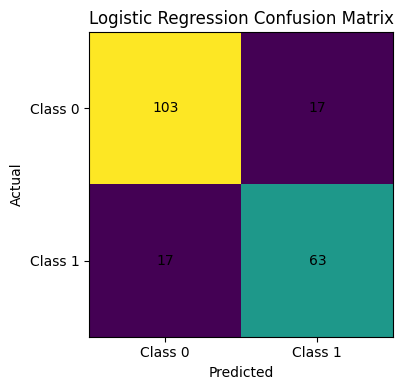

In [17]:
# ML-08 Section 4: Errors and interpretation

# -----------------------------
# Confusion matrix
# -----------------------------
cm = confusion_matrix(y_test, model_pred)

tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix")
print("================")
print(cm)

print("\nError breakdown")
print("----------------")
print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)


# -----------------------------
# Error rate
# -----------------------------
total_errors = fp + fn
total_test = len(y_test)

error_rate = total_errors / total_test

print("\nTotal incorrect predictions:", total_errors)
print("Total test observations    :", total_test)
print("Error rate                 :", round(error_rate, 4))


# -----------------------------
# Feature interpretation
# -----------------------------
trained_model = logistic_model.named_steps["model"]

coefficients = trained_model.coef_[0]

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Absolute_Importance": np.abs(coefficients)
})

feature_importance = feature_importance.sort_values(
    "Absolute_Importance",
    ascending=False
)

print("\nFeature importance")
print("==================")

display(
    feature_importance.round(4)
)


# -----------------------------
# Strongest feature
# -----------------------------
strongest = feature_importance.iloc[0]

print("\nInterpretation")
print("-------------")

print(
    f"The model relies most strongly on {strongest['Feature']} "
    f"based on the largest absolute coefficient."
)

print(
    f"Its coefficient is {strongest['Coefficient']:.4f}."
)

if strongest["Coefficient"] > 0:
    print(
        "The positive coefficient means higher values of this "
        "feature are associated with a higher probability of class 1."
    )
else:
    print(
        "The negative coefficient means higher values of this "
        "feature are associated with a lower probability of class 1."
    )


# -----------------------------
# Confusion matrix plot
# -----------------------------
fig, ax = plt.subplots(figsize=(5, 4))

ax.imshow(cm)

ax.set_title("Logistic Regression Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels(["Class 0", "Class 1"])
ax.set_yticklabels(["Class 0", "Class 1"])

for i in range(2):
    for j in range(2):
        ax.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.